# statsmodels — task-indexed cheatsheet


statsmodels covers the *classical* time-series toolkit: stationarity tests, ARIMA / SARIMAX, exponential smoothing, ACF/PACF plots, Ljung-Box and other residual diagnostics. Compared to sklearn, it's more academic — you get full statistical summaries, p-values, and confidence intervals for everything.

When to reach for statsmodels over sklearn: you have a univariate time series and want **interpretable** structure (trend / seasonality / autoregression), or you need formal hypothesis tests (stationarity, residual whiteness, parameter significance).


---
## Setup

Run this once.


### Setup — run me first


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Synthetic AR(1) + seasonal (24-period) + trend series.
rng = np.random.default_rng(0)
n = 500
trend = np.linspace(100, 110, n)
seasonal = 2 * np.sin(2 * np.pi * np.arange(n) / 24)
ar1 = np.zeros(n)
phi = 0.5
for t in range(1, n):
    ar1[t] = phi * ar1[t-1] + rng.normal(0, 1)
y = pd.Series(trend + seasonal + ar1,
              index=pd.date_range('2024-01-01', periods=n, freq='1h', tz='UTC'))
returns = y.diff().dropna()

---
## 1. Stationarity tests

Most time-series methods assume stationarity. Two canonical tests with **opposite null hypotheses**: ADF says "there's a unit root (non-stationary)"; KPSS says "the series is stationary". Run both — agreement is reassuring, disagreement is informative.


### How do I run an Augmented Dickey-Fuller test?

`adfuller(series)` — null: series has a unit root. Reject (small p) ⇒ stationary.


In [2]:
from statsmodels.tsa.stattools import adfuller

stat, pval, *_ = adfuller(returns)
print(f'ADF stat = {stat:.3f}, p = {pval:.4f}')
print('reject H0 (stationary)' if pval < 0.05 else 'fail to reject (unit root)')

ADF stat = -11.377, p = 0.0000
reject H0 (stationary)


*Common mistake*: running ADF on `y` (the level), getting p > 0.05, and concluding 'non-stationary therefore useless'. The standard fix is to **difference** until stationary — `y.diff()` once is usually enough.


### How do I run a KPSS test?

`kpss(series, regression='c')` — null: series is stationary. Reject (small p) ⇒ non-stationary.


In [3]:
from statsmodels.tsa.stattools import kpss

stat, pval, *_ = kpss(returns, regression='c', nlags='auto')
print(f'KPSS stat = {stat:.3f}, p = {pval:.4f}')
print('reject H0 (non-stationary)' if pval < 0.05 else 'fail to reject (stationary)')

KPSS stat = 0.016, p = 0.1000
fail to reject (stationary)


/tmp/ipykernel_2750935/1231109873.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, *_ = kpss(returns, regression='c', nlags='auto')


*Why both ADF and KPSS*: their nulls are flipped, so a definitive answer requires agreement. ADF reject + KPSS not-reject ⇒ stationary. ADF not-reject + KPSS reject ⇒ non-stationary. Disagreement (e.g. both fail to reject) ⇒ the data is between regimes — try differencing.


---
## 2. Trend / seasonal decomposition

Splitting a series into trend, seasonal, and residual components. Use STL for robustness; classical decomposition is a faster fallback.


### How do I do an STL decomposition?

`STL(series, period=...).fit()` returns `.trend`, `.seasonal`, `.resid` series.


In [4]:
from statsmodels.tsa.seasonal import STL

stl = STL(y, period=24, robust=True).fit()
print(f'trend std:    {stl.trend.std():.3f}')
print(f'seasonal std: {stl.seasonal.std():.3f}')
print(f'residual std: {stl.resid.std():.3f}')

trend std:    2.918
seasonal std: 1.450
residual std: 0.897


*When to use*: complex seasonality, or when classical decomposition gives obviously-wrong residuals. *Common mistake*: forgetting `period=` — for hourly data with daily seasonality it's 24; for weekly seasonality 168; for monthly 12.


### How do I do a classical seasonal decomposition?

`seasonal_decompose(series, model='additive', period=...)`. Faster than STL but less robust.


In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

dec = seasonal_decompose(y, model='additive', period=24)
print(f'seasonal std (classical): {dec.seasonal.std():.3f}')

seasonal std (classical): 1.337


*When to use*: quick first-look at seasonality. *additive vs multiplicative*: additive when seasonal swing is constant; multiplicative when seasonal swing scales with the level (e.g. retail sales — busier holidays in years with more total sales).


### How do I compute strength of seasonality?

$F_s = \max(0, 1 - \mathrm{Var}(R) / \mathrm{Var}(S+R))$. Close to 1 ⇒ strong seasonality; 0 ⇒ none.


In [6]:
S, R = stl.seasonal.dropna(), stl.resid.dropna()
common = S.index.intersection(R.index)
Fs = max(0.0, 1.0 - R[common].var() / (S[common] + R[common]).var())
print(f'F_s strength of seasonality: {Fs:.3f}')

F_s strength of seasonality: 0.731


*When to use*: deciding whether seasonal features are worth engineering. F_s < 0.1 ⇒ probably not.


---
## 3. ACF and PACF — what lags matter

ACF measures correlation between the series and its lag-k self. PACF removes the influence of intermediate lags. Both are foundational for choosing AR / MA orders.


### How do I plot the ACF?

`plot_acf(series, lags=40, ax=ax)`.


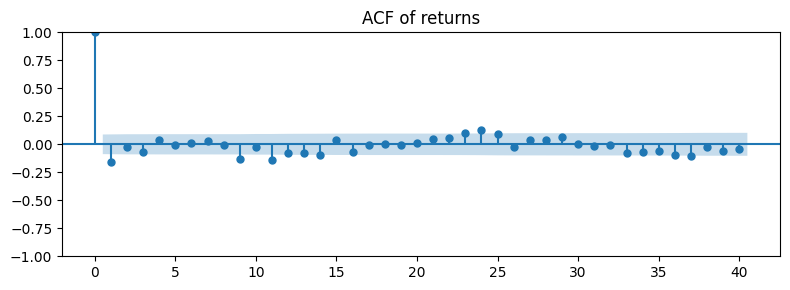

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(returns, lags=40, ax=ax)
ax.set_title('ACF of returns'); plt.tight_layout(); plt.show()

*How to read*: bars outside the blue band are significant at 5%. *Common mistake*: confusing lag 0 (always = 1, trivially) with lag 1 (the interesting one).


### How do I plot the PACF?

`plot_pacf(series, lags=40, ax=ax)`. Use PACF to identify AR order; ACF for MA order.


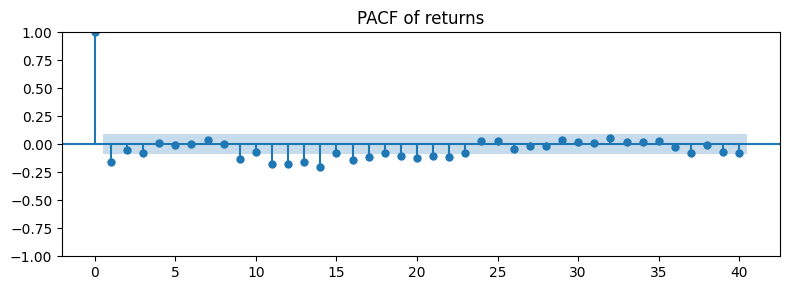

In [8]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(8, 3))
plot_pacf(returns, lags=40, ax=ax, method='ywm')
ax.set_title('PACF of returns'); plt.tight_layout(); plt.show()

*Rule of thumb*: PACF cuts off after lag p ⇒ AR(p). ACF cuts off after lag q ⇒ MA(q). Both decay slowly ⇒ ARMA(p, q) needed.


### How do I get the ACF as numbers?

`acf(series, nlags=40)` returns the array.


In [9]:
from statsmodels.tsa.stattools import acf

ac = acf(returns, nlags=10)
print('ACF lags 0-10:')
for k, val in enumerate(ac):
    print(f'  lag {k:>2}: {val:+.4f}')

ACF lags 0-10:
  lag  0: +1.0000
  lag  1: -0.1603
  lag  2: -0.0229
  lag  3: -0.0665
  lag  4: +0.0391
  lag  5: -0.0058
  lag  6: +0.0103
  lag  7: +0.0315
  lag  8: -0.0046
  lag  9: -0.1349
  lag 10: -0.0273


*When to use*: programmatic checks (e.g. assert |acf(resid)[1:24].max()| < 0.05 to confirm residuals are white).


---
## 4. Exponential smoothing (Holt-Winters / ETS)

Old-school but surprisingly competitive. Hand-tunes level, trend, and seasonal components via exponential smoothing parameters.


### How do I fit Holt-Winters with seasonality?

`ExponentialSmoothing(y, trend='add', seasonal='add', seasonal_periods=24).fit()`.


In [10]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

train, test = y.iloc[:-24], y.iloc[-24:]
hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=24).fit()
forecast = hw.forecast(24)
print(f'forecast MAE: {(forecast.values - test.values).__abs__().mean():.3f}')

forecast MAE: 0.815


*When to use*: quick benchmark for any seasonal series. *Common mistake*: forgetting `seasonal_periods=` — defaults make assumptions that often don't fit.


### How do I get the smoothing parameters back?

`fit.params['smoothing_level']` (alpha), `'smoothing_trend'` (beta), `'smoothing_seasonal'` (gamma).


In [11]:
print(f'alpha (level):    {hw.params.get("smoothing_level", float("nan")):.3f}')
print(f'beta  (trend):    {hw.params.get("smoothing_trend", float("nan")):.3f}')
print(f'gamma (seasonal): {hw.params.get("smoothing_seasonal", float("nan")):.3f}')

alpha (level):    0.461
beta  (trend):    0.000
gamma (seasonal): 0.000


*How to read*: alpha ≈ 1 ⇒ trust the latest observation; alpha ≈ 0 ⇒ heavy smoothing. *When to use*: sanity-check whether the model's smoothing levels make sense for your data.


---
## 5. SARIMA

Seasonal ARIMA — `(p, d, q) × (P, D, Q, s)`. The strongest classical time-series model and a benchmark every ML approach should beat.


### How do I fit a SARIMA model?

`SARIMAX(y, order=(p, d, q), seasonal_order=(P, D, Q, s)).fit(disp=False)`.


In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Small ARIMA(1, 0, 0) on stationary returns.
sarima = SARIMAX(returns, order=(1, 0, 0)).fit(disp=False)
print(f'AR(1) coef: {sarima.params[0]:.3f}')
print(f'AIC: {sarima.aic:.1f}')

AR(1) coef: -0.160
AIC: 1613.0


*Reading the AIC*: lower is better; differences > 2 are noteworthy. *Common mistake*: leaving `disp=True` and getting flooded with optimiser output. Always pass `disp=False`.


### How do I forecast h steps ahead?

`fit.forecast(h)` for point forecasts; `fit.get_forecast(h)` for forecasts + intervals.


In [13]:
fc = sarima.get_forecast(steps=24)
print(f'first 5 point forecasts:')
print(fc.predicted_mean.head().round(4).tolist())
print(f'first row 95% CI: [{fc.conf_int().iloc[0, 0]:.3f}, {fc.conf_int().iloc[0, 1]:.3f}]')

first 5 point forecasts:
[0.2157, -0.0346, 0.0055, -0.0009, 0.0001]
first row 95% CI: [-2.162, 2.594]


*Common mistake*: confusing `forecast()` (no intervals) with `get_forecast()` (returns object with `.conf_int()`). Use `get_forecast` whenever you need uncertainty.


### How do I run a small grid search over SARIMA orders?

Loop over `(p, q)` combinations, fit, sort by AIC. Don't go too wide — fits are expensive.


In [14]:
results = []
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        try:
            m = SARIMAX(returns, order=(p, 0, q)).fit(disp=False)
            results.append({'p': p, 'q': q, 'aic': m.aic})
        except Exception:
            pass
results = pd.DataFrame(results).sort_values('aic')
print(results.head())

   p  q          aic
7  2  1  1584.528530
5  1  2  1584.704333
8  2  2  1585.134418
1  0  1  1611.667906
4  1  1  1612.301790


*Why limit p, q to small values*: high orders fit but rarely generalise; AIC penalises but not enough. *Common mistake*: searching `d` ≥ 1 — over-differencing destroys signal. Difference manually first if needed.


---
## 6. Residual diagnostics

Once you've fitted a model, check whether the residuals look like white noise. If they don't, the model has missed something.


### How do I run the Ljung-Box test on residuals?

`acorr_ljungbox(resid, lags=[12, 24], return_df=True)`. Null: residuals are uncorrelated. p > 0.05 at every lag is what you want.


In [15]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(sarima.resid, lags=[1, 12, 24], return_df=True)
print(lb.round(4))

    lb_stat  lb_pvalue
1    0.0348     0.8520
12  39.5575     0.0001
24  83.5182     0.0000


*How to read*: p < 0.05 at any lag ⇒ residuals still have autocorrelation; the model didn't capture some pattern. *Common mistake*: testing too many lags and getting a spurious significant result by chance.


### How do I plot residuals + ACF + Q-Q in one panel?

`fit.plot_diagnostics(figsize=...)` does it all in a 2×2 grid.


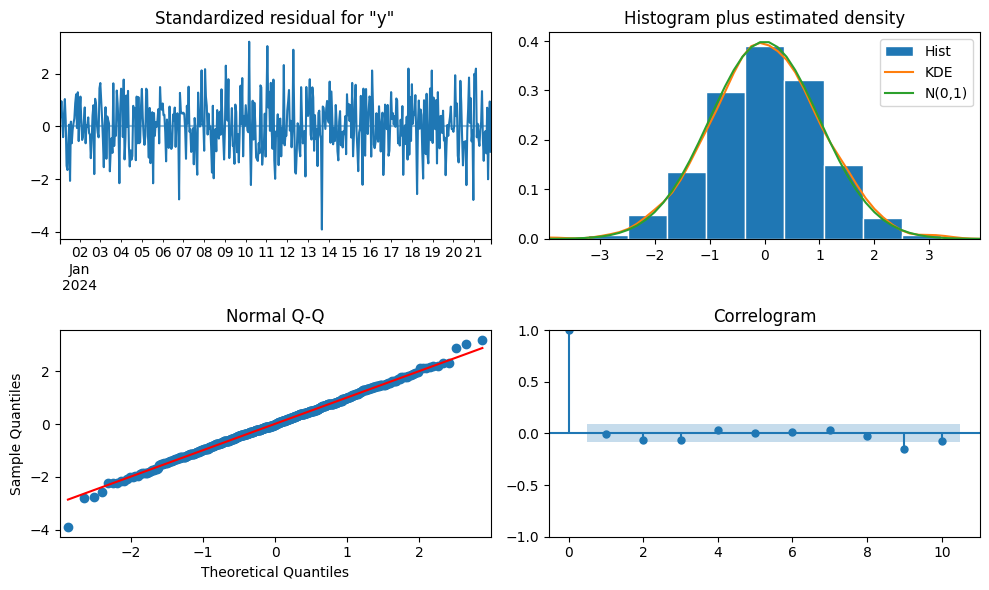

In [16]:
fig = sarima.plot_diagnostics(figsize=(10, 6))
plt.tight_layout(); plt.show()

*What the four panels show*: top-left = standardised residuals over time (should be flat); top-right = histogram + KDE vs N(0, 1); bottom-left = Q-Q plot vs Normal (should follow the diagonal); bottom-right = ACF (should be inside the bands).
